In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# 1. Download the VADER lexicon (only needs to be run once)
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ahmed\AppData\Roaming\nltk_data...


True

Imported Libraries and downloading the vader rule based sentiment analyzer

In [2]:
print("Loading cleaned dataset...")
df = pd.read_csv('data/cleaned/cleaned_dataset.csv')

# Initialize the VADER analyzer
analyzer = SentimentIntensityAnalyzer()

Loading cleaned dataset...


Calculating sentiment scores. This may take a few minutes...
Saving dataset with sentiment features...
Saved as sentiment_dataset.csv!

--- Generating EDA Visualizations ---


C:\Users\ahmed\AppData\Local\Temp\ipykernel_15832\3945303779.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='sentiment_score', data=df, palette='seismic')


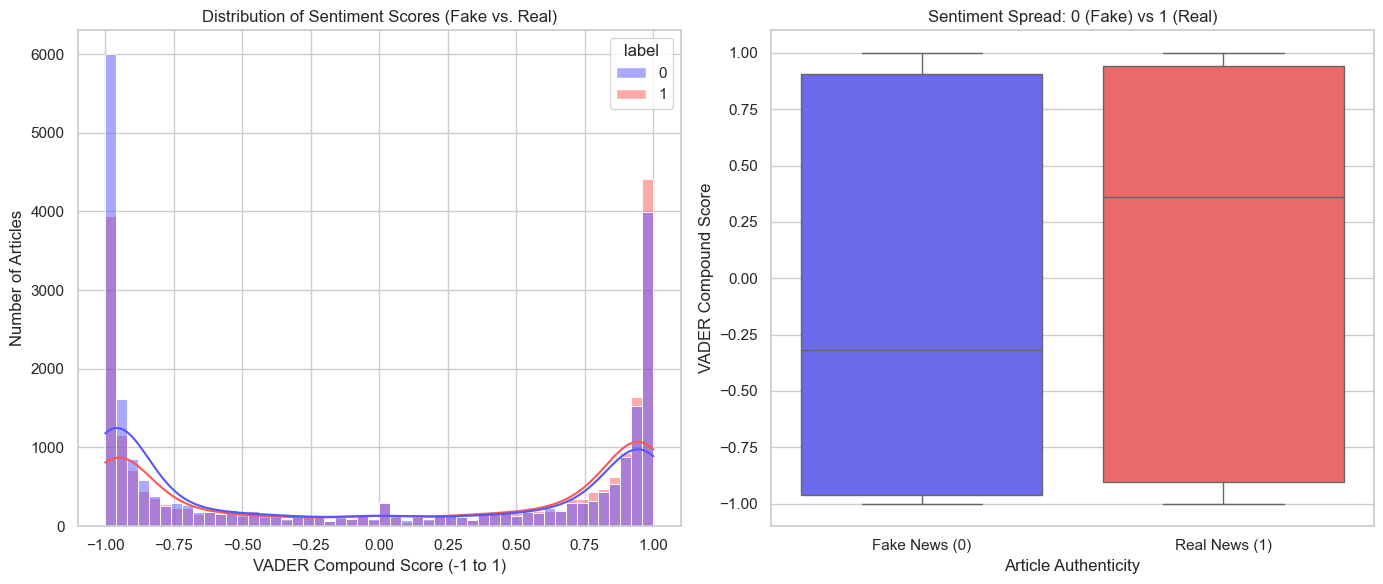


--- Average Sentiment Scores ---
label
0   -0.083414
1    0.084824
Name: sentiment_score, dtype: float64


In [ ]:
def get_vader_compound(text):
    """
    Returns the VADER compound sentiment score.
    Ranges from -1 (Extremely Negative) to +1 (Extremely Positive).
    """
    # Handle any NaN values that might have slipped through
    if not isinstance(text, str):
        return 0.0
    
    # Calculate the sentiment polarity
    scores = analyzer.polarity_scores(text)
    return scores['compound']

print("Calculating sentiment scores. This may take a few minutes...")
# Apply the function to create a new feature column
df['sentiment_score'] = df['full_text'].apply(get_vader_compound)


print("Saving dataset with sentiment features...")
# Save this enriched dataset for Models 1-5 to use!
df.to_csv('data/cleaned/sentiment_dataset.csv', index=False)
print("Saved as sentiment_dataset.csv!")

# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================
print("\n--- Generating EDA Visualizations ---")

# Set the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Histogram of Sentiment Scores
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='sentiment_score', hue='label', bins=50, kde=True, palette='seismic')
plt.title('Distribution of Sentiment Scores (Fake vs. Real)')
plt.xlabel('VADER Compound Score (-1 to 1)')
plt.ylabel('Number of Articles')

# Plot 2: Boxplot for clear statistical differences
plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='sentiment_score', data=df, hue='label', palette='seismic', legend=False)
plt.title('Sentiment Spread: 0 (Fake) vs 1 (Real)')
plt.xlabel('Article Authenticity')
plt.ylabel('VADER Compound Score')
plt.xticks([0, 1], ['Fake News (0)', 'Real News (1)'])

plt.tight_layout()
plt.show()

# Print out some basic statistical comparisons
print("\n--- Average Sentiment Scores ---")
print(df.groupby('label')['sentiment_score'].mean())